# Exp 3: Anomaly Score Distribution Visualization

Loads a trained Deep SVDD, computes anomaly scores for two datasets,  
and plots overlapping histograms (in-distribution vs OOD).

**Prerequisites:**  
- `weights/SVDD_hopper-medium-v2.pth` must exist  
- `weights/pretrained_parameters_hopper-medium-v2.pth` must exist

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import gym
import d4rl  # noqa

from svdd.svdd import network
from svdd.dataset import D4RLDataset

/home/stinm36/anaconda3/envs/rlocc/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/stinm36/anaconda3/envs/rlocc/lib/python3.8/site-packages/Cython/Distutils/old_build_ext.py:15: DeprecationWarning: dep_util is Deprecated. Use functions from setuptools instead.
  from distutils.dep_util import newer, newer_group
No module named 'flow'
No module named 'carla'
pybullet build time: Nov 28 2023 23:51:11
/home/stinm36/anaconda3/envs/rlocc/lib/python3.8/site-packages/pybullet_envs/env_bases.py:8: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import parse_version
/home/stinm36/anaconda3/envs/rlocc/lib/python3.8/site-packages/pkg_resources/__init__.py:2832: DeprecationWarning: Deprecated call to `pkg_resources.decl

In [2]:
# ── Configuration ────────────────────────────────────────────────────────────
ENV_ID      = 'hopper-medium-v2'           # SVDD was trained on this
OOD_ENV_ID  = 'hopper-medium-replay-v2'   # out-of-distribution dataset
SVDD_TAG    = ''                           # e.g. 'e200_s0' if you used --svdd_tag

HIDDEN_DIM  = 256
LATENT_DIM  = 128
BATCH_SIZE  = 512
BINS        = 100

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cuda:0


In [3]:
def load_svdd(env_name, hidden_dim, latent_dim, svdd_tag, device):
    tag    = ('_' + svdd_tag) if svdd_tag else ''
    wpath  = f'../weights/SVDD_{env_name}{tag}.pth'
    ppath  = f'../weights/pretrained_parameters_{env_name}.pth'

    env  = gym.make(env_name)
    obs_dim    = env.observation_space.low.size
    action_dim = env.action_space.low.size
    env.close()

    svdd = network(obs_dim, action_dim, hidden_dim, latent_dim).to(device)
    svdd.load_state_dict(torch.load(wpath, map_location=device))
    svdd.eval()

    state_dict = torch.load(ppath, map_location=device)
    c = torch.tensor(state_dict['center'], dtype=torch.float32).to(device)
    print(f'Loaded SVDD: {wpath}')
    return svdd, c

svdd, c = load_svdd(ENV_ID, HIDDEN_DIM, LATENT_DIM, SVDD_TAG, DEVICE)

/home/stinm36/anaconda3/envs/rlocc/lib/python3.8/site-packages/gym/spaces/box.py:84: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Loaded SVDD: ../weights/SVDD_hopper-medium-v2.pth


In [4]:
@torch.no_grad()
def compute_scores(dataset_name, svdd, c, device, batch_size=512):
    dataset = D4RLDataset(dataset_name)
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    scores  = []
    for x in loader:
        x = x.float().to(device)
        z = svdd(x)
        s = torch.sqrt(torch.sum((z - c) ** 2, dim=1))
        scores.append(s.cpu().numpy())
    return np.concatenate(scores)

print(f'Computing scores for {ENV_ID}...')
scores_id  = compute_scores(ENV_ID,     svdd, c, DEVICE, BATCH_SIZE)
print(f'Computing scores for {OOD_ENV_ID}...')
scores_ood = compute_scores(OOD_ENV_ID, svdd, c, DEVICE, BATCH_SIZE)

print(f'In-dist  n={len(scores_id):,}  mean={scores_id.mean():.4f}  std={scores_id.std():.4f}')
print(f'OOD      n={len(scores_ood):,}  mean={scores_ood.mean():.4f}  std={scores_ood.std():.4f}')

Computing scores for hopper-medium-v2...


load datafile: 100%|██████████| 21/21 [00:00<00:00, 25.75it/s]


Computing scores for hopper-medium-replay-v2...


load datafile: 100%|██████████| 11/11 [00:00<00:00, 35.52it/s]


In-dist  n=999,998  mean=0.0025  std=0.0018
OOD      n=401,598  mean=0.0136  std=0.0195


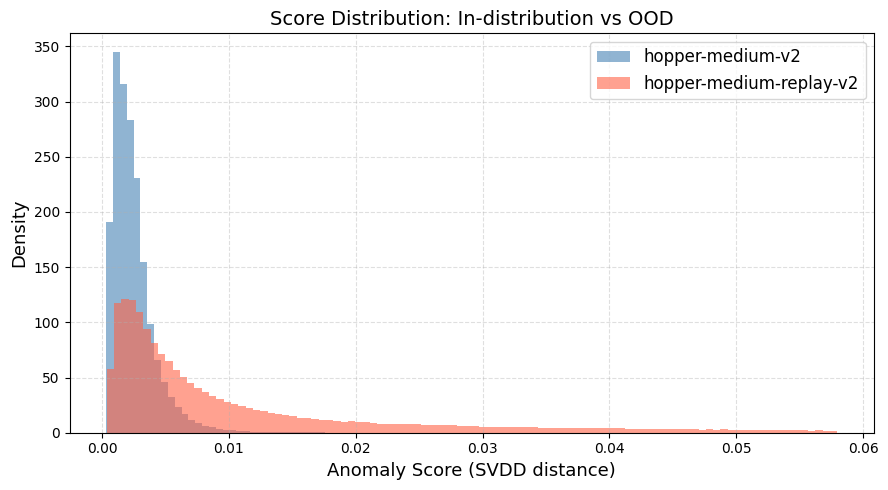

Saved to ../results/exp3_score_dist_hopper-medium-v2.png


In [5]:
# Clip outliers at 99th percentile for readability
p99 = np.percentile(np.concatenate([scores_id, scores_ood]), 99)
id_clipped  = scores_id[scores_id   <= p99]
ood_clipped = scores_ood[scores_ood <= p99]

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(id_clipped,  bins=BINS, density=True, alpha=0.6,
        color='steelblue', label=ENV_ID)
ax.hist(ood_clipped, bins=BINS, density=True, alpha=0.6,
        color='tomato',    label=OOD_ENV_ID)

ax.set_xlabel('Anomaly Score (SVDD distance)', fontsize=13)
ax.set_ylabel('Density', fontsize=13)
ax.set_title('Score Distribution: In-distribution vs OOD', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()

os.makedirs('../results', exist_ok=True)
out = f'../results/exp3_score_dist_{ENV_ID}.png'
plt.savefig(out, dpi=150)
plt.show()
print(f'Saved to {out}')